# Week 3 — Day 3: Logistic Regression & Classification Metrics

**BinX Tech AI & ML Internship**

This notebook builds and evaluates a binary **Logistic Regression** classifier using the Breast Cancer Wisconsin dataset from Scikit-learn.

### Day 3 Goals
- Understand why Logistic Regression is a classification algorithm.
- Connect `z = Xw + b` to the sigmoid probability.
- Compare `predict()` with `predict_proba()`.
- Evaluate the classifier with a confusion matrix.
- Interpret accuracy, precision, recall, and F1-score.
- Understand why accuracy alone can be misleading.
- Compare the trained model against a simple baseline.
- Evaluate threshold-independent discrimination with ROC-AUC.
- Keep preprocessing leakage-free.

## 1. Imports

The workflow uses:
- **Pandas / NumPy** for data handling.
- **Matplotlib** for visualizations.
- **Scikit-learn** for splitting, preprocessing, modeling, baselines, and evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

## 2. Load the Classification Dataset

The original Scikit-learn target uses:

- `0 = malignant`
- `1 = benign`

For this notebook, the target is reversed so the **important positive class is malignant**:

- `1 = Malignant`
- `0 = Benign`

This definition matters because TP, FP, FN, precision, and recall are interpreted relative to the positive class.

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)

# Define the clinically important class as the positive class.
y = pd.Series((data.target == 0).astype(int), name="malignant")

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nMissing values:", X.isna().sum().sum())
print("\nFirst five rows:")
display(X.head())

Feature matrix shape: (569, 30)
Target shape: (569,)

Missing values: 0

First five rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Inspect the Target Distribution

Before training a classifier, inspect the target distribution.

Why:
- A large class imbalance can make **accuracy misleading**.
- It tells us what a majority-class baseline can achieve without learning useful patterns.
- It helps us decide whether metrics such as precision, recall, and F1 deserve more attention.

The class distribution plot uses:
- **X-axis:** target class.
- **Y-axis:** number of samples.
- **ML decision:** do not rely on accuracy alone if one class dominates.

,Count,Percentage
Benign (0),357,62.741652
Malignant (1),212,37.258348


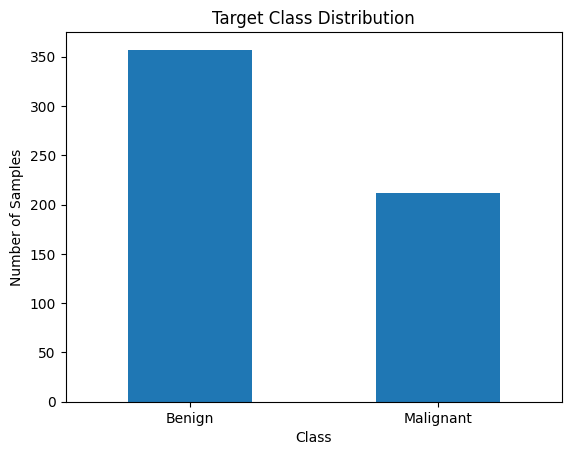

In [3]:
class_counts = y.value_counts().sort_index()
class_percentages = (y.value_counts(normalize=True).sort_index() * 100)

distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})
distribution.index = ["Benign (0)", "Malignant (1)"]

display(distribution)

class_counts.index = ["Benign", "Malignant"]
class_counts.plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Target Class Distribution")
plt.xticks(rotation=0)
plt.show()

### Observation

The dataset is not perfectly balanced, but the imbalance is moderate rather than extreme.  
A majority-class model would still achieve noticeable accuracy by predicting only `Benign`, so a proper classifier should be evaluated with richer metrics and against a baseline.

## 4. Train/Test Split

A held-out test set is required for honest evaluation.

`stratify=y` preserves approximately the same class proportions in both training and test sets.  
This is especially useful in classification because an unlucky random split can distort the representation of the minority class.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (455, 30)
X_test : (114, 30)
y_train: (455,)
y_test : (114,)


In [5]:
split_distribution = pd.DataFrame({
    "Full Dataset": y.value_counts(normalize=True).sort_index(),
    "Train": y_train.value_counts(normalize=True).sort_index(),
    "Test": y_test.value_counts(normalize=True).sort_index()
}) * 100

split_distribution.index = ["Benign (0)", "Malignant (1)"]

display(split_distribution.round(2))

,Full Dataset,Train,Test
Benign (0),62.74,62.64,63.16
Malignant (1),37.26,37.36,36.84


## 5. Leakage-Free Feature Scaling

Logistic Regression is optimized numerically, and this dataset contains features on very different scales.

The scaler must learn its statistics **only from the training data**:

```python
scaler.fit_transform(X_train)
scaler.transform(X_test)
```

Using `fit_transform()` on the full dataset or on the test set would leak test-set information into the training workflow.

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape    :", X_test_scaled.shape)

Scaled training shape: (455, 30)
Scaled test shape    : (114, 30)


## 6. Train Logistic Regression

Logistic Regression starts with a linear score:

\[
z = Xw + b
\]

The sigmoid function maps that score to a value between 0 and 1:

\[
\sigma(z)=\frac{1}{1+e^{-z}}
\]

The resulting value is interpreted as a probability for the positive class.  
Training finds coefficients and an intercept that minimize the logistic objective on the training data.

In [7]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


## 7. Inspect the Learned Parameters

- `model.coef_` contains the learned feature weights.
- `model.intercept_` contains the learned bias.

Because the features were standardized, coefficient magnitudes are more directly comparable than they would be on the original raw scales.

A positive coefficient pushes the prediction toward `Malignant (1)` as that standardized feature increases; a negative coefficient pushes it toward `Benign (0)`, holding other features constant.

These coefficients describe the model's association structure and should **not** be interpreted as causal effects.

In [8]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values("Absolute_Coefficient", ascending=False)

print("Intercept:", model.intercept_[0])
display(coefficients.head(10))

Intercept: -0.24300532690558876


,Feature,Coefficient,Absolute_Coefficient
21,worst texture,1.434093,1.434093
10,radius error,1.233325,1.233325
28,worst symmetry,1.061264,1.061264
7,mean concave points,0.952813,0.952813
26,worst concavity,0.911406,0.911406
13,area error,0.909029,0.909029
15,compactness error,-0.906925,0.906925
23,worst area,0.900477,0.900477
20,worst radius,0.896968,0.896968
6,mean concavity,0.782298,0.782298


## 8. `predict_proba()` vs `predict()`

`predict_proba()` returns class probabilities:

```text
[P(class 0), P(class 1)]
```

Since `1 = Malignant`, column `[:, 1]` is the probability of malignancy.

`predict()` returns the final class decision. With the default binary decision rule, probabilities at or above the decision threshold are assigned to the positive class.

In [9]:
probabilities = model.predict_proba(X_test_scaled)
positive_probabilities = probabilities[:, 1]

predictions = model.predict(X_test_scaled)

results = pd.DataFrame({
    "Actual": y_test.values,
    "P(Malignant)": positive_probabilities,
    "Predicted": predictions
})

display(results.head(10))

,Actual,P(Malignant),Predicted
0,0,0.000365,0
1,1,1.000000,1
2,0,0.042568,0
3,1,0.576187,1
4,0,0.509155,1
5,0,0.000616,0
6,1,0.761534,1
7,0,0.001012,0
8,0,0.000569,0
9,0,0.010768,0


### Manual Threshold Check

The following cell reproduces the default `0.5` class decision from the positive-class probabilities.

This demonstrates the chain:

```text
features → linear score → sigmoid probability → threshold → class
```

In [10]:
manual_predictions = (positive_probabilities >= 0.5).astype(int)

print("Manual threshold predictions match model.predict():",
      np.array_equal(manual_predictions, predictions))

Manual threshold predictions match model.predict(): True


## 9. Confusion Matrix

For this problem:

- **TP:** malignant and correctly predicted malignant.
- **TN:** benign and correctly predicted benign.
- **FP:** benign but incorrectly flagged as malignant.
- **FN:** malignant but incorrectly predicted benign.

The visualization uses:
- **X-axis:** predicted label.
- **Y-axis:** true label.
- **ML interpretation:** the types of errors matter more than the total number of errors. In screening, false negatives are especially important because they represent missed malignant cases.

True Negatives : 71
False Positives: 1
False Negatives: 3
True Positives : 39


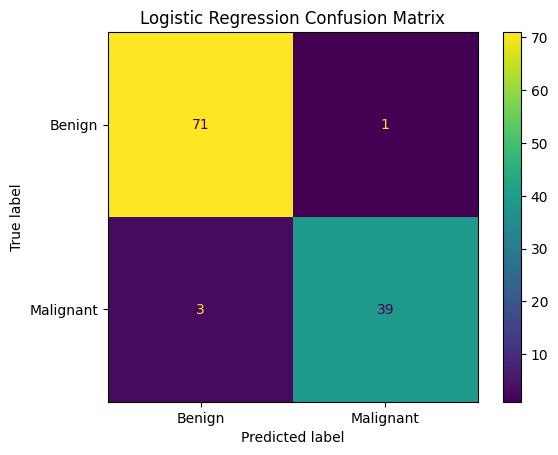

In [11]:
cm = confusion_matrix(y_test, predictions)
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Benign", "Malignant"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation

With this fixed split, the model produces:

- **71 TN:** benign cases correctly classified as benign.
- **39 TP:** malignant cases correctly detected.
- **1 FP:** one benign case incorrectly flagged as malignant.
- **3 FN:** three malignant cases incorrectly classified as benign.

The three false negatives are the most important errors in a screening context because they correspond to malignant cases that were missed.

## 10. Classification Metrics

Each metric answers a different question:

- **Accuracy:** What fraction of all predictions were correct?
- **Precision:** Of all cases predicted malignant, how many were actually malignant?
- **Recall:** Of all truly malignant cases, how many were detected?
- **F1-score:** How well are precision and recall balanced?

Accuracy is useful, but it should not be interpreted alone when class frequencies or error costs are unequal.

In [12]:
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy, precision, recall, f1]
})

display(metrics.round(4))

,Metric,Score
0,Accuracy,0.9649
1,Precision,0.9750
2,Recall,0.9286
3,F1-score,0.9512


### Metric Interpretation

The model has very high precision for the malignant class, so a malignant prediction is usually correct.

Recall is slightly lower because the model missed three malignant cases. For a screening-style problem, recall deserves particular attention because reducing false negatives can be more important than maximizing overall accuracy.

F1-score summarizes the balance between precision and recall, but the final metric priority should still reflect the real cost of the two error types.

## 11. Classification Report

`classification_report` shows precision, recall, and F1-score for both classes.

`support` is the number of true samples belonging to each class; it is not a performance metric.

- **Macro average:** gives each class equal weight.
- **Weighted average:** weights each class by its number of samples.

In [13]:
print(
    classification_report(
        y_test,
        predictions,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## 12. Majority-Class Baseline

A classification model should beat a simple reference strategy.

The baseline below always predicts the most frequent class. It can obtain non-trivial accuracy without learning any relationship between the features and the target.

Comparing against it prevents a high-looking accuracy from being mistaken for useful learning.

In [14]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_scaled, y_train)

baseline_predictions = baseline.predict(X_test_scaled)
baseline_probabilities = baseline.predict_proba(X_test_scaled)[:, 1]

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, baseline_predictions),
    "Precision": precision_score(y_test, baseline_predictions, zero_division=0),
    "Recall": recall_score(y_test, baseline_predictions, zero_division=0),
    "F1-score": f1_score(y_test, baseline_predictions, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, baseline_probabilities)
}

model_auc = roc_auc_score(y_test, positive_probabilities)

model_metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "ROC-AUC": model_auc
}

comparison = pd.DataFrame({
    "Logistic Regression": model_metrics,
    "Majority Baseline": baseline_metrics
})

display(comparison.round(4))

,Logistic Regression,Majority Baseline
Accuracy,0.9649,0.6316
Precision,0.9750,0.0000
Recall,0.9286,0.0000
F1-score,0.9512,0.0000
ROC-AUC,0.9960,0.5000


### Baseline Interpretation

The majority baseline predicts every case as benign. It therefore achieves some accuracy simply because benign cases are more common, but it has:

- zero recall for malignant cases,
- zero F1 for the malignant class,
- no useful discrimination.

The Logistic Regression model clearly adds predictive value beyond this trivial strategy.

## 13. ROC Curve and AUC

The ROC curve evaluates the classifier across many decision thresholds.

- **X-axis — False Positive Rate (FPR):** fraction of actual benign cases incorrectly flagged as malignant.
- **Y-axis — True Positive Rate (TPR):** fraction of actual malignant cases correctly detected; this is the same as recall.
- The diagonal reference represents random-ranking performance.
- A curve closer to the **top-left corner** indicates stronger separation between the classes.

**AUC** summarizes the ROC curve in one number. It measures how well the model ranks positive cases above negative cases independently of one fixed threshold.

ROC-AUC: 0.9960


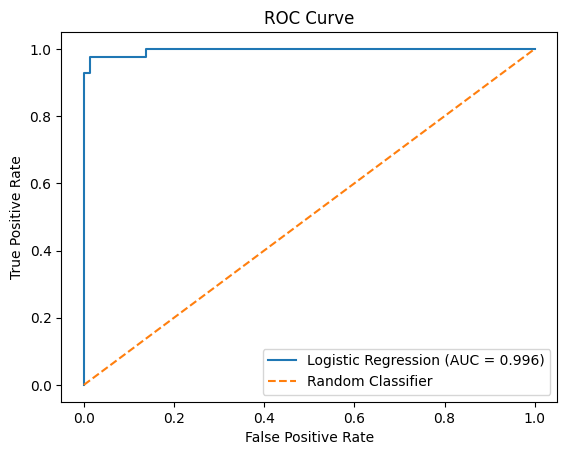

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, positive_probabilities)
auc = roc_auc_score(y_test, positive_probabilities)

print(f"ROC-AUC: {auc:.4f}")

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### ROC-AUC Interpretation

The ROC-AUC is approximately **0.996**, indicating that the model separates malignant and benign cases extremely well on this held-out test set.

AUC evaluates ranking quality across thresholds, while the confusion matrix, precision, recall, and F1 describe the behavior of the final class decisions at a specific threshold.

A strong AUC does not automatically determine the best deployment threshold. If threshold tuning is required, it should be performed on validation data or through cross-validation — **not by repeatedly optimizing against the test set**.

## 14. Final Evaluation

For the fixed test split, Logistic Regression achieved approximately:

| Metric | Score |
|---|---:|
| Accuracy | 0.965 |
| Precision | 0.975 |
| Recall | 0.929 |
| F1-score | 0.951 |
| ROC-AUC | 0.996 |

The confusion matrix shows **39 malignant cases detected and 3 missed**. The model also produced only **1 false positive**.

### ML Decision

The model performs strongly and clearly beats the majority-class baseline. However, because the positive class represents malignancy, **recall is especially important**: false negatives are more consequential than false alarms in a screening context.

The current model therefore should not be judged by accuracy alone. A real deployment would define an acceptable false-negative cost and, if necessary, tune the decision threshold using validation data while monitoring the precision–recall trade-off.

## 15. Key Learning Outcomes

- Logistic Regression is a **classification** model even though it contains a linear component.
- `z = Xw + b` is converted to a probability through the sigmoid function.
- `predict_proba()` exposes probabilities; `predict()` returns class decisions.
- The confusion matrix separates errors into TP, TN, FP, and FN.
- Accuracy can be misleading when class distributions are uneven.
- Precision focuses on false positives; recall focuses on false negatives.
- F1-score balances precision and recall.
- ROC-AUC evaluates discrimination across decision thresholds.
- The best evaluation metric depends on the real-world cost of mistakes.
- Scaling was fit on the training set only, preventing preprocessing leakage.
- A trained model should be compared against a simple baseline before claiming that it adds value.